# Source: https://scikit-learn.org/stable/auto_examples/decomposition/plot_image_denoising.html

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import numpy as np
import sklearn
import scipy.linalg as LA
import matplotlib.pyplot as plt

from time import time
from sklearn.decomposition import SparseCoder, sparse_encode
from sklearn.linear_model import orthogonal_mp_gram

from skimage.metrics import structural_similarity as ssim

seed = 42
rng = np.random.default_rng(seed)

## Import test image from scipy

In [2]:
from scipy.datasets import face

raccoon_face = face(gray=True).astype(np.float64)

# normalize
raccoon_face /= 255.0

# downsample for speed
raccoon_face = raccoon_face[::4, ::4] + raccoon_face[2::4, ::4] + raccoon_face[::4, 2::4] + raccoon_face[2::4, 2::4]
raccoon_face /= 4
height, width = raccoon_face.shape

# Distort the right half of the image
print('Distorting image')
distorted = raccoon_face.copy()
distorted[:, width // 2:] += .075 * rng.standard_normal(size=(height, width // 2))

Distorting image


## Display distorted image

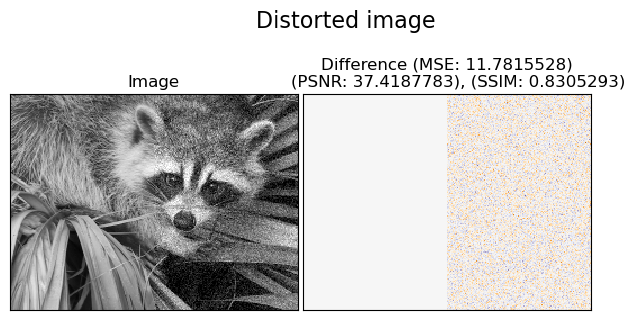

In [3]:
def show_with_diff(image, reference, title):
    plt.figure(figsize=(7, 3.3))
    plt.subplot(1, 2, 1)
    plt.title('Image')
    plt.imshow(image, vmin=0, vmax=1, cmap=plt.cm.gray, interpolation='nearest')
    plt.xticks(())
    plt.yticks(())
    
    plt.subplot(1, 2, 2)
    difference = image - reference

    MSE = np.sqrt(np.sum(difference**2))
    PSNR = 20 * np.log10(255 / np.sqrt(MSE))
    SSIM = ssim(reference, image, data_range = 1)
    
    plt.title(f'''Difference (MSE: {MSE:.7f})
    (PSNR: {PSNR:.7f}), (SSIM: {SSIM:.7f})''')
    
    plt.imshow(
        difference, vmin=-0.5, vmax=0.5, cmap=plt.cm.PuOr, interpolation='nearest'
    )
    plt.xticks(())
    plt.yticks(())
    plt.suptitle(title, size=16)
    plt.subplots_adjust(.02, .02, .85, .77, .02, .2)

show_with_diff(distorted, raccoon_face, 'Distorted image')

## Extract reference patches

In [4]:
from time import time
from sklearn.feature_extraction.image import extract_patches_2d

# Extract patches from left half of the image
print('Extracting reference patches')
t0 = time()
patch_size = (7, 7)
data = extract_patches_2d(distorted[:, :width // 2], patch_size)
data = data.reshape(data.shape[0], -1)
data -= np.mean(data, axis=0)
data /= np.std(data, axis=0)
print(f'{data.shape[0]} patches extracted in %.2fs.' % (time() - t0))

Extracting reference patches
22692 patches extracted in 0.03s.


# Serial_V5 KSVD implementation

In [5]:
import numpy as np
import sklearn
import scipy.linalg as LA
import matplotlib.pyplot as plt

from time import time
from sklearn.decomposition import SparseCoder, sparse_encode
from sklearn.linear_model import orthogonal_mp_gram


def OMP(Y, T_0, D, batch_size = 1, rng=42, debug=False, float_dtype=np.float32):
    int_dtype = np.int32
    
    X = np.zeros((Y.shape[0], D.shape[0]), order='F', dtype=float_dtype)
    D_norm = np.linalg.norm(D, axis=1, keepdims=True)
    
    splits = np.arange(0, Y.shape[0], step=batch_size, dtype=int_dtype)

    Y_batches = np.split(Y, splits)[1:]
    batch_idx = np.arange(batch_size, dtype=int_dtype)
    
    for i, y in enumerate(Y_batches):
        
        if i == (len(Y_batches) - 1):
            batch_size = np.arange(splits[i], len(Y), dtype=int_dtype).shape[0]
            batch_idx = batch_idx[:batch_size]
            if debug:
                print(f'batch_size = {batch_size}')
                
        I = np.empty((batch_size, T_0), dtype=int_dtype)
        D_I = np.zeros((batch_size, T_0, D.shape[1]), dtype=float_dtype)

        # Deep copy to not overwrite Y
        r = y.copy()   # (batch_size, D.shape[1])
        # r = y.astype(float_dtype)
        gamma = 0
        
        # Q = np.empty((batch_size, D.shape[1], T_0))
        Q = np.empty((batch_size, T_0, D.shape[1]), dtype=float_dtype)
        
        Q_T_y = np.empty((batch_size, T_0), order='F', dtype=float_dtype)
        # R = np.empty((batch_size, T_0, T_0))
        R = np.zeros((batch_size, T_0, T_0), order='F', dtype=float_dtype)
        

        # Create a mask to ensure duplicates aren't selected
        atom_mask = np.ones((batch_size, D.shape[0]), dtype=float_dtype)

        global_dead_batches = np.zeros(batch_size, dtype=bool)
        j_stop = T_0
        
        for j in range(T_0):
            if debug:
                print(f'Batch {i}, Iteration {j}')
                print(f'r shape: {r.shape}')

            # Check if any batch is alive otherwise, exit loop
            if np.all(global_dead_batches):
                j_stop = j
                break

            # Find best dictionary atom  

            # Let B = batch_size
            # matmul: (B, D.shape[1]) @ (D.shape[1], D.shape[0]) -> (B, D.shape[0])
            D_r = r @ D.T
            D_r *= atom_mask
            np.abs(D_r, out=D_r)
            
            # max, axis = 1: (B, D.shape[0]) -> (B,)
            k = np.argmax(D_r, axis = 1)

            atom_mask[batch_idx, k] = 0
            
            I[:, j] = k
            # D_I[:, j] = D[k]

            # Adv Indexing: (B,) -> (B, D.shape[1])
            D_k = D[k]

            # Gram-Schmidt
            if j == 0:
                # Adv Indexing: (B,) -> (B, 1)
                D_k_norm = D_norm[k]
                R[:, 0, 0] = D_k_norm[:, 0]
                Q[:, 0] = D_k / D_k_norm
                
                
            else:
                if debug:
                    print(Q[:, :j].shape)
                    print(D_k[..., np.newaxis].shape)
                    
                # Batched mat mul: (B, j, D.shape[1]) @ (B, D.shape[1], 1) -> (B, j, 1)
                # squeeze: (B, j, 1) -> (B, j)
                dot = np.squeeze(Q[:, :j] @ D_k[..., np.newaxis], axis=-1)
                R[:, 0:j, j] = dot

                # Orthogonalize
                # Batched mat mul: (B, 1, j) @ (B, j, D.shape[1]) -> (B, 1, D.shape[1])
                # squeeze: (B, 1, D.shape[1]) -> (B, D.shape[1])
                # subtraction: (B, D.shape[1]) - (B, D.shape[1]) -> (B, D.shape[1])
                q_j = D_k - np.squeeze(dot[:, np.newaxis] @ Q[:, :j], axis = 1)
                
                
                # norm, axis = 1: (B, D.shape[1]) -> (B,)
                q_j_norm = np.linalg.norm(q_j, axis = 1)
                

                # STABILITY FIX
                # Instead of just Q[:, :, j] = q_j / q_j_norm[:, np.newaxis]
                dead_batches = (q_j_norm < 1e-15)

                global_dead_batches |= dead_batches
                q_j[dead_batches] = 0
                atom_mask[dead_batches, k[dead_batches]] = 1
                
                q_j_norm_safe = q_j_norm
                q_j_norm_safe[dead_batches] = 1 # Avoid division by zero
                Q[:, j] = q_j / q_j_norm_safe[:, np.newaxis]
                
                R[:, j, j] = q_j_norm
                # Q[:, :, j] = q_j / q_j_norm[:, np.newaxis]
                
                if debug:            
                    print(Q[:, :j+1].shape)
                    print(y.shape)


            # sum, axis=1: (B, D.shape[1]) -> (B,)
            if debug and j == (T_0 - 1):
                print(f'y dtype: {y.dtype}')
                print(f'Q dtype: {Q.dtype}')
                
            y_proj = np.sum(y * Q[:, j], axis = 1, dtype=float_dtype)
            Q_T_y[:, j] = y_proj

            # mul: (B, D.shape[1]) * (B, 1) -> (B, D.shape[1])
            r -= Q[:, j] * y_proj[:, np.newaxis]

                
            if debug:
                # print(gamma.shape)
                # print(f'D_I shape: {D_I[:, :j+1].shape}')
                print(f'y shape: {y.shape}')
            # est = np.squeeze(gamma[:, np.newaxis] @ D_I[:, :j+1], axis=1)
                # print(f'est shape: {est.shape}')
            # r = y - est
            # r = y_ortho_proj

                print(f'r shape: {r.shape}')
                # print(f'error = {np.sum(r * r, axis = -1)}')

        
        # gamma = np.linalg.solve(R[:, :j_stop, :j_stop], Q_T_y[:, :j_stop, np.newaxis])
        # gamma = np.squeeze(gamma, axis=-1)
        gamma = np.empty((batch_size, j_stop), dtype=float_dtype)
        for n in range(1, j_stop+1):
            idx = j_stop - n
            gamma_idx = Q_T_y[:, idx] / R[:, idx, idx]
            gamma[:, idx] = gamma_idx
            Q_T_y[:, :idx] -= gamma_idx[:, np.newaxis] * R[:, :idx, idx]
        

        rows = 0
        cols = I[:, :j_stop]
        if i == (len(Y_batches) - 1):
            if debug:
                # print(splits[i].dtype)
                # print(I.dtype)
                # print(f'gamma: {gamma}')
                print(f'gamma shape: {gamma.shape}')
                print(f'k shape: {k.shape}')
                print(f'I shape: {I.shape}')
            rows = np.arange(splits[i], len(Y), dtype=int_dtype)[:, np.newaxis]
            
        elif i == 0:
            rows = np.arange(0, splits[1], dtype=int_dtype)[:, np.newaxis]
        else:
            rows = np.arange(splits[i], splits[i+1], dtype=int_dtype)[:, np.newaxis]

        X[rows, cols] = gamma

        if debug:
            print()
    return X


def kSVD(Y, T_0, k, num_iter, 
         batch_size = 1, 
         track_loss = True, 
         verbose:int = 0, 
         rng = 42,
         dtype = np.float32):
    loss = np.empty(num_iter, dtype=dtype)
    rng = np.random.default_rng(rng)

    if dtype != np.float64 and dtype != np.float32:
        print('Only FP32 or FP64 is supported!')
        print('Setting the dtype to FP32...')
        dtype = np.float32
    
    # Initialize dictionary
    t0 = time()
    D = rng.standard_normal(size=(k, Y.shape[1]), dtype=dtype)
    D /= LA.norm(D, ord=2, axis=1)[:, np.newaxis]

    if verbose > 0:
        print(f'Initialization Time: {time() - t0}')

    if Y.dtype != dtype:
        if verbose > 0:
            print("dtype arg doesn't match Y dtype!")
            print('Creating a copy of Y with the specified dtype...')
        Y = Y.astype(dtype)
    
    for iter in range(num_iter):
        t0 = 0
        if verbose > 0:
            print(f'Iteration {iter}:')
            t0 = time()
        
        # gram = D @ D.T
        # cov = D @ Y.T
        # X = orthogonal_mp_gram(
        #     Gram=gram, 
        #     Xy=cov, 
        #     n_nonzero_coefs=T_0, 
        #     copy_Gram=False, 
        #     copy_Xy=False
        # ).T # Transpose to match X shape
        X = OMP(Y, T_0, D, 
                batch_size = batch_size, 
                rng=rng, 
                debug=(verbose > 1), 
                float_dtype=dtype)
        # X = np.asfortranarray(X)
        if verbose > 0:
            print(f'\tCoding Time: {time() - t0}')
        
        t0 = time()
        unused_atom = False
        # XD = X @ D
        filter_bool = (X != 0)
        # matmul: (Y.shape[0], k) @ (k, Y.shape[1]) -> (Y.shape[0], Y.shape[1]) 
        # E_k_R = Y - X @ D
        E_k_R = np.subtract(Y, X @ D, dtype=dtype)
        
        for i in range(k):
            # x_i = X[:, i]
            filter_bool_i = filter_bool[:, i]
            
            # filter = np.flatnonzero(x_i)
            # filter = np.nonzero(x_i)[0]
            filter = np.flatnonzero(filter_bool_i)
            
            # x_i_R = x_i[filter]
            
            # if x_i_R.shape[0] == 0:
            if filter.shape[0] == 0:
                unused_atom=True
                # sum, axis=1: (Y.shape[0], Y.shape[1]) -> (Y.shape[0], )
                atom_error = np.sum(E_k_R ** 2, axis=1, dtype=dtype)
                atom_idx = np.argmax(atom_error)

                D_i_new = Y[atom_idx]
                D_i_new /= np.linalg.norm(D_i_new)
                D[i] = D_i_new

                X[atom_idx, i] = 1
                E_k_R[atom_idx] = 0
                if verbose > 0:
                    print(f'Replaced dict atom {i} with data point {atom_idx}')
                continue
            
            # res = X[filter, i][:, np.newaxis] * D[i]
            # XD[filter] -= res
            # E_k_R = Y[filter] - XD[filter]
            E_k_R[filter] += X[filter, i][:, np.newaxis] * D[i]

            # U, S, Vh = LA.svd(E_k_R, full_matrices=False)
            # U, S, Vh = LA.svd(E_k_R[filter], full_matrices=False)
            U, S, Vh = np.linalg.svd(E_k_R[filter], full_matrices=False)

            X[filter, i] = U[:, 0] * S[0]
            D[i] = Vh[0]

            # XD[filter] += X[filter, i][:, np.newaxis] * D[i]
            E_k_R[filter] -= X[filter, i][:, np.newaxis] * D[i]

        if verbose > 0:
            print(f'\tUpdate Time: {time() - t0}')
            print(f'\tUnused Atom Detected: {unused_atom}')
        
        # loss[iter] = LA.norm(Y - XD, ord='fro')
        loss[iter] = LA.norm(E_k_R, ord='fro')

    return D, loss

In [6]:
def plot_log_loss(loss, linestyle='-', alpha = 1):
    plt.semilogy(loss, linestyle=linestyle, alpha = alpha)
    plt.title('Loss vs iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Loss (Log Scale)')
    # plt.show()

## Learn the dictionary from reference patches

### Hyperparams have been set to try to match those in the sklearn example and the results obtained for a more fair comparison!

In [7]:
num_iter = 2
Y = data
T_0 = 1
batch_size = 256
dtype = np.float32

Learning the dictionary
Initialization Time: 0.0
dtype arg doesn't match Y dtype!
Creating a copy of Y with the specified dtype...
Iteration 0:
	Coding Time: 0.033029794692993164
Replaced dict atom 79 with data point 16404
Replaced dict atom 209 with data point 16894
	Update Time: 0.14699983596801758
	Unused Atom Detected: True
Iteration 1:
	Coding Time: 0.030999422073364258
	Update Time: 0.1586015224456787
	Unused Atom Detected: False
Total Time: 0.38.


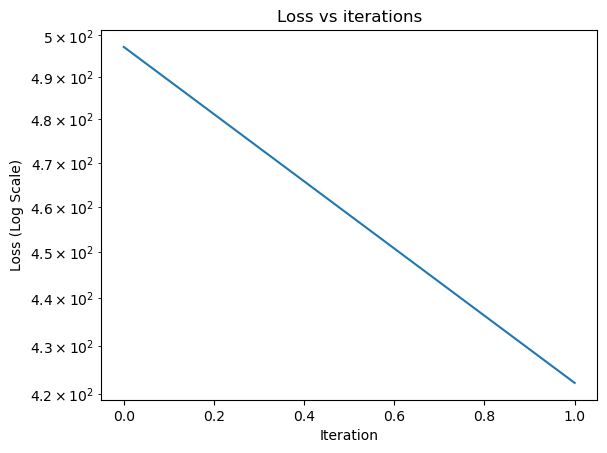

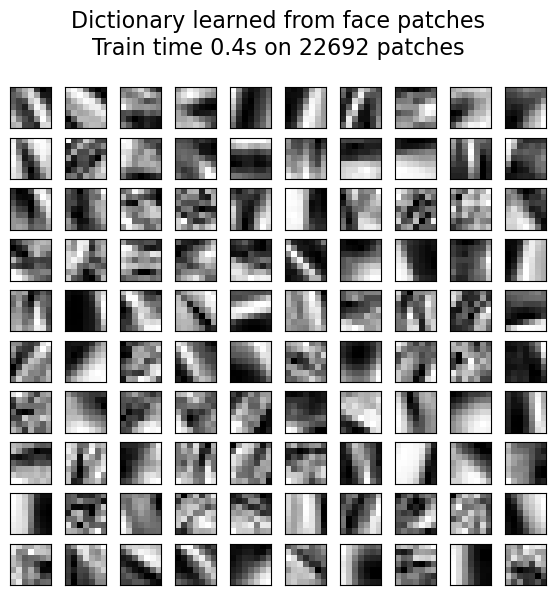

In [8]:
print('Learning the dictionary')
t0 = time()
D, loss = kSVD(Y = Y, 
               T_0 = T_0, 
               k = 300, 
               num_iter = num_iter, 
               verbose=1,
               rng = rng,
               batch_size = batch_size,
               dtype = dtype)
dt = time() - t0
print(f'Total Time: {dt:.2f}.')
plot_log_loss(loss)

plt.figure(figsize=(6.5, 6))
for i, comp in enumerate(D[:100]):
    plt.subplot(10, 10, i+1)
    plt.imshow(comp.reshape(patch_size), cmap=plt.cm.gray_r, interpolation='nearest')
    plt.xticks(())
    plt.yticks(())
plt.suptitle(
    'Dictionary learned from face patches\n'
    + 'Train time %.1fs on %d patches' % (dt, len(Y)),
    fontsize=16,
)
plt.subplots_adjust(.08, .02, .92, .85, .08, .23)

## Extract noisy patches and reconstruct them using the dictionary

In [9]:
from sklearn.feature_extraction.image import reconstruct_from_patches_2d

print('Extracting noisy patches...')
t0 = time()
data_test = extract_patches_2d(distorted[:, width // 2 :], patch_size)
data_test = data_test.reshape(data_test.shape[0], -1)
intercept = np.mean(data_test, axis=0)
data_test -= intercept
print('done in %.2fs.' % (time() - t0))

Extracting noisy patches...
done in 0.01s.


OMP
1 atom...
done in 1.67s.
OMP
2 atoms...
done in 3.24s.
Thresholding
 alpha = 0.1...
done in 0.29s.


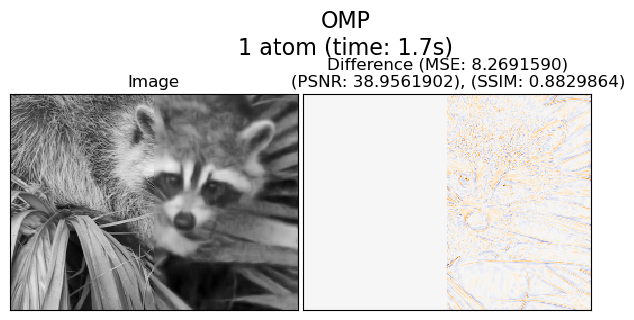

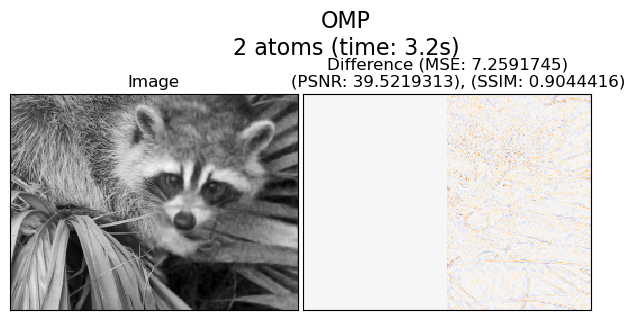

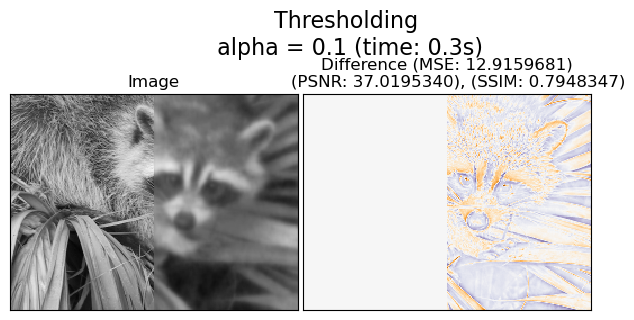

In [10]:
transform_algorithms = [
('OMP\n1 atom', 'omp', {'transform_n_nonzero_coefs': 1}),
('OMP\n2 atoms', 'omp', {'transform_n_nonzero_coefs': 2}),
# ('Lars\n4 atoms', 'lars', {'transform_n_nonzero_coefs': 4}),
('Thresholding\n alpha = 0.1', 'threshold', {'transform_alpha': 0.1}),
]

reconstructions = {}
for title, transform_algorithm, kwargs in transform_algorithms:
    print(title + '...')
    reconstructions[title] = raccoon_face.copy()
    t0 = time()
    coder = SparseCoder(transform_algorithm=transform_algorithm,
                        dictionary = D,
                        **kwargs)
    code = coder.transform(data_test)
    patches = code @ D

    patches += intercept
    patches = patches.reshape(len(data_test), *patch_size)
    if transform_algorithm == 'threshold':
        patches -= patches.min()
        patches /= patches.max()
    reconstructions[title][:, width // 2 :] = reconstruct_from_patches_2d(
        patches, (height, width // 2)
    )
    dt = time() - t0
    print('done in %.2fs.' % dt)
    show_with_diff(reconstructions[title], 
                   raccoon_face, 
                   title + ' (time: %.1fs)' % dt
                  )

plt.show()

## Compare with Custom OMP

Custom OMP
1 atom...
done in 0.17s.
Custom OMP
2 atoms...
done in 0.20s.


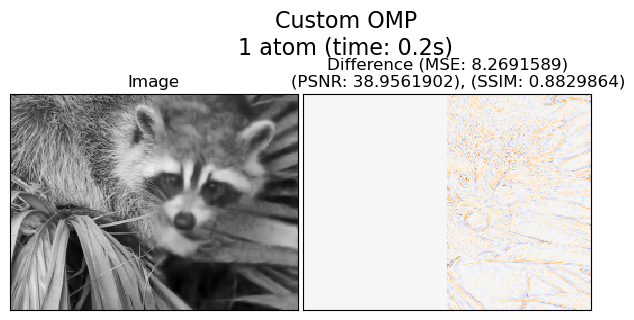

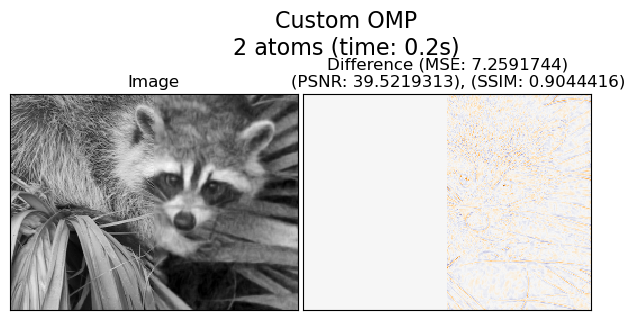

In [11]:
OMP_Params = [
('Custom OMP\n1 atom', {'T_0': 1}),
('Custom OMP\n2 atoms', {'T_0': 2}),
]

reconstructions = {}
data_test2 = data_test.astype(dtype)
for title, kwargs in OMP_Params:
    print(title + '...')
    reconstructions[title] = raccoon_face.copy()
    t0 = time()
    # coder = SparseCoder(transform_algorithm=transform_algorithm,
    #                     dictionary = D,
    #                     **kwargs)
    # code = coder.transform(data_test)
# def OMP(Y, T_0, D, batch_size = 1, rng=42, debug=False, float_dtype=np.float32):
    # D_normalized = D / np.linalg.norm(D, axis = 1, keepdims = True)
    code = OMP(data_test2, kwargs['T_0'], D, batch_size=batch_size, rng=rng, float_dtype=dtype)
    patches = code @ D

    patches += intercept
    patches = patches.reshape(len(data_test), *patch_size)
    # if transform_algorithm == 'threshold':
    #     patches -= patches.min()
    #     patches /= patches.max()
    reconstructions[title][:, width // 2 :] = reconstruct_from_patches_2d(
        patches, (height, width // 2)
    )
    dt = time() - t0
    print('done in %.2fs.' % dt)
    show_with_diff(reconstructions[title], 
                   raccoon_face, 
                   title + ' (time: %.1fs)' % dt
                  )

plt.show()

# Compare with MiniBatchDictionaryLearning used in the scikit-learn example

Learning the dictionary...
1.0 iterations / 101 steps in 34.66.


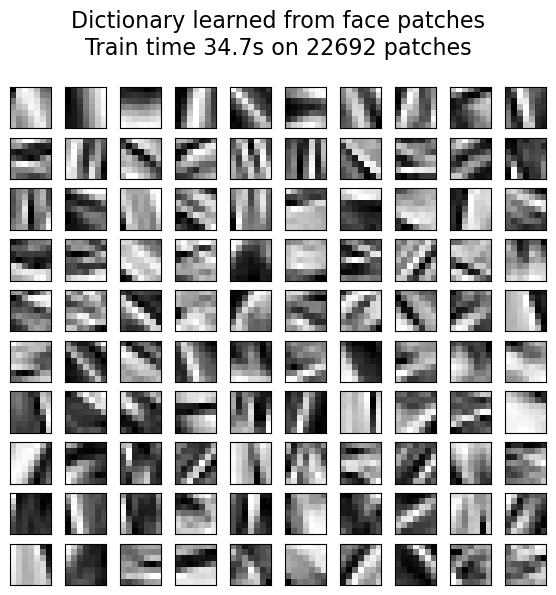

In [12]:
from sklearn.decomposition import MiniBatchDictionaryLearning

print('Learning the dictionary...')
t0 = time()
dico = MiniBatchDictionaryLearning(
    n_components=300,
    batch_size=200,
    alpha=1.0,
    max_iter=10,
    random_state = seed,
)
V = dico.fit(data).components_
dt = time() - t0
print(f'{dico.n_iter_} iterations / {dico.n_steps_} steps in {dt:.2f}.')

plt.figure(figsize=(6.5, 6))
for i, comp in enumerate(V[:100]):
    plt.subplot(10, 10, i+1)
    plt.imshow(comp.reshape(patch_size), cmap=plt.cm.gray_r, interpolation='nearest')
    plt.xticks(())
    plt.yticks(())
plt.suptitle(
    'Dictionary learned from face patches\n'
    + 'Train time %.1fs on %d patches' % (dt, len(data)),
    fontsize=16,
)
plt.subplots_adjust(.08, .02, .92, .85, .08, .23)

OMP
1 atom...
done in 2.02s.
OMP
2 atoms...
done in 3.34s.
Thresholding
 alpha = 0.1...
done in 0.35s.


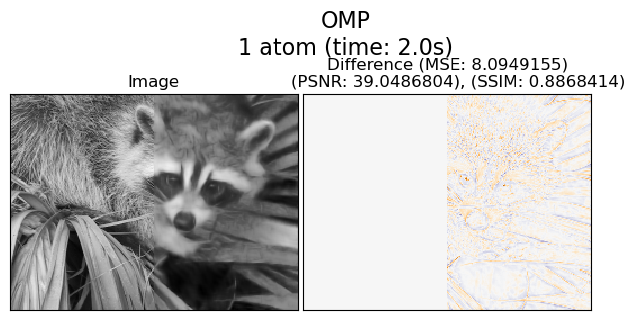

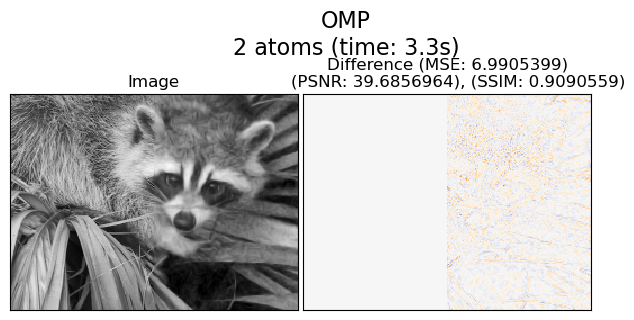

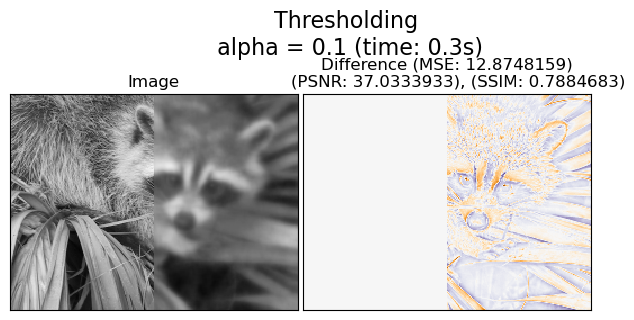

In [13]:
reconstructions = {}
for title, transform_algorithm, kwargs in transform_algorithms:
    print(title + '...')
    reconstructions[title] = raccoon_face.copy()
    t0 = time()
    # coder = SparseCoder(transform_algorithm=transform_algorithm,
    #                     dictionary = D,
    #                     **kwargs)
    # code = coder.transform(data_test)
    # patches = code @ D
    
    dico.set_params(transform_algorithm=transform_algorithm, **kwargs)
    code = dico.transform(data_test)
    patches = np.dot(code, V)
    
    patches += intercept
    patches = patches.reshape(len(data_test), *patch_size)
    if transform_algorithm == 'threshold':
        patches -= patches.min()
        patches /= patches.max()
    reconstructions[title][:, width // 2 :] = reconstruct_from_patches_2d(
        patches, (height, width // 2)
    )
    dt = time() - t0
    print('done in %.2fs.' % dt)
    show_with_diff(reconstructions[title], 
                   raccoon_face, 
                   title + ' (time: %.1fs)' % dt
                  )

plt.show()